# Sensitivity to assumption of constant age-group distribution within countries

- Take WorldPop data
- Remap to 0.5 degrees
- Use instead of my gridscale_global population data to test present-day warming level exposure (or for a certain year that I have in WorldPop)
- Make a sensitivity figure for the supplements

In [1]:
import xarray as xr
import rioxarray
import glob
import numpy as np


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# import my variables settings functions from other scripts
from settings import *
from functions import *


[1771328196.529387] [node510:1507941:0]     ucp_context.c:1081 UCX  WARN  transport 'cuda' is not available, please use one or more of: cma, dc, dc_mlx5, dc_x, ib, mm, posix, rc, rc_mlx5, rc_v, rc_verbs, rc_x, self, shm, sm, sysv, tcp, ud, ud_mlx5, ud_v, ud_verbs, ud_x
[1771328196.650360] [node510:1507941:0]     ucp_context.c:1081 UCX  WARN  transport 'cuda' is not available, please use one or more of: cma, dc, dc_mlx5, dc_x, ib, mm, posix, rc, rc_mlx5, rc_v, rc_verbs, rc_x, self, shm, sm, sysv, tcp, ud, ud_mlx5, ud_v, ud_verbs, ud_x


In [4]:
figdir = os.path.join(figdirs, 'fig_feb26/worldpop/')
os.makedirs(figdir, exist_ok=True)

In [5]:

# NEW: plot model median and range - rename fxn

def plot_barplot_n_prop_people_atleastx_modelmedian(da, 
                                                  unit, 
                                                  ax, 
                                                  year=2022, 
                                                  proportion=False, 
                                                  x_hot_days = [1,5,10,20,50],
                                                 legend=True,
                                                 errcolor='gray',
                                                 color=None,
                                                 alpha=1,
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel=None, 
                                                 label=None,
                                                 offset=0,
                                                 ):
    # plot range 
    if unit == 1e9:
        unit_str = 'billions'
    elif unit == 1e6:
        unit_str='millions'
    else:
        unit_str = ''

    upper_error = (da.max(dim='model')-da.astype(float).median(dim='model')).values.T /unit
    lower_error = (da.astype(float).median(dim='model')-da.min(dim='model')).values.T /unit
    try:
        concatenated =np.concatenate((lower_error,upper_error), axis=1)
        reshaped = np.reshape(concatenated, (len(da.features), 2, len(da.age_ranges)))
    except:
        concatenated =np.concatenate((lower_error,upper_error))
        reshaped = np.reshape(concatenated, (2, len(da.age_ranges)))

    # plot multi-model mean 
    if color == None:
        (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
                                                   yerr=reshaped,
                                                   error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1))
    else:
        (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
                                                   yerr=reshaped,
                                                         color=color,
                                                         alpha=alpha,
                                                         label=label,
                                                   error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1))        
    if ylabel is None:
        if proportion:
            ax.set_ylabel(f'Proportion of age group (%)')

        else:
            ax.set_ylabel(f'Number of people ({unit_str})')
    else:
        ax.set_ylabel(ylabel)

    ax.set_xlabel(' ')
    
    if set_xticklabel:
        step_ages = int(da.age_ranges[1] -da.age_ranges[0] - 1)
        ax.set_xticks(ticks=ax.get_xticks(), labels=[f'{x}-{x+step_ages}' for x in da.age_ranges.values],  
                      rotation=rotation, rotation_mode='anchor',ha='right') #'horizontal'
    else:
        ax.set_xticklabels('')
    
    if legend==True:
        if not label:
            ax.legend(labels = [f'at least {x}' for x in x_hot_days])


In [6]:

# NEW: plot model median and range - rename fxn

def plot_barplot_n_prop_people_atleastx_modelmedian(da, 
                                                  unit, 
                                                  ax, 
                                                  year=2022, 
                                                  proportion=False, 
                                                  x_hot_days = [1,5,10,20,50],
                                                 legend=True,
                                                 errcolor='gray',
                                                 color=None,
                                                 alpha=1,
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel=None, 
                                                 label=None,
                                                 offset=0,
                                                 ):
    # plot range 
    if unit == 1e9:
        unit_str = 'billions'
    elif unit == 1e6:
        unit_str='millions'
    else:
        unit_str = ''

    upper_error = (da.max(dim='model')-da.astype(float).median(dim='model')).values.T /unit
    lower_error = (da.astype(float).median(dim='model')-da.min(dim='model')).values.T /unit
    try:
        concatenated =np.concatenate((lower_error,upper_error), axis=1)
        reshaped = np.reshape(concatenated, (len(da.features), 2, len(da.age_ranges)))
    except:
        concatenated =np.concatenate((lower_error,upper_error))
        reshaped = np.reshape(concatenated, (2, len(da.age_ranges)))

    # get the median values as pandas Series
    y = (da.astype(float).median(dim='model')/unit).to_pandas()
    x = np.arange(len(y))  # default positions for bars

    x_shifted = x + offset
    yerr=reshaped

    # # plot multi-model mean 
    # if color == None:
    #     (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
    #                                                yerr=reshaped,
    #                                                error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1))
    # else:
    #     (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
    #                                                yerr=reshaped,
    #                                                      color=color,
    #                                                      alpha=alpha,
    #                                                      label=label,
                                                 #  error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1))     

    
    # then plot using ax.bar instead of pandas plot
    ax.bar(
        x_shifted, y, 
        yerr=yerr, 
        width=0.4,       # narrower than 1.0 to allow spacing
        color=color,
        alpha=alpha,
        label=label,
        error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1)
    )

    # replace the x-ticks with the original positions
    ax.set_xticks(x)
    step_ages = int(da.age_ranges[1] - da.age_ranges[0] - 1)
    ax.set_xticklabels([f'{x}-{x+step_ages}' for x in da.age_ranges.values], rotation=40, ha='right')

    if ylabel is None:
        if proportion:
            ax.set_ylabel(f'Proportion of age group (%)')

        else:
            ax.set_ylabel(f'Number of people ({unit_str})')
    else:
        ax.set_ylabel(ylabel)

    ax.set_xlabel(' ')
    
    if set_xticklabel:
        step_ages = int(da.age_ranges[1] -da.age_ranges[0] - 1)
        ax.set_xticks(ticks=ax.get_xticks(), labels=[f'{x}-{x+step_ages}' for x in da.age_ranges.values],  
                      rotation=rotation, rotation_mode='anchor',ha='right') #'horizontal'
    else:
        ax.set_xticklabels('')
    
    if legend==True:
        if not label:
            ax.legend(labels = [f'at least {x}' for x in x_hot_days])


In [7]:
def plot_percapitadays_median_iqr(df_plot, 
                                  ax,
                                  set_xticklabel=True,
                                  ylabel='Per capita attributable \nhot-humid days per year',
                                 rotation=40, 
                                 offset=0,
                                 widths=.4
                                 ):
    
    
    medianprops = dict(color='k',linewidth=2)
    whiskerprops = dict(color='none')
    capprops = dict(color='none')

    plot = ax.boxplot(df_plot,  
                      whiskerprops=whiskerprops, 
                      capprops=capprops, 
                      medianprops=medianprops,
                      patch_artist=True,
                      showfliers=False,
                      positions=np.arange(len(df_plot.columns)) + offset,  # <-- shift here
                      widths=widths,
                      ) #boxprops=boxprops,

    col='cadetblue'
    for patch in plot['boxes']:
            patch.set_facecolor(col)
            patch.set_edgecolor(col)

    if set_xticklabel:
        ax.set_xticks(np.arange(len(df_plot.columns)))  # original positions for x-ticks
        ax.set_xticklabels([f'{x}-{x+9}' for x in df_plot.columns], 
                           rotation=rotation, rotation_mode='anchor', ha='right')
    else:
        ax.set_xticklabels('')

    plt.ylabel(ylabel)

    return plot


## open Worldpop data

In [8]:
ages = np.arange(0,85,5)
ages = np.insert(ages, 1, 1)

In [9]:


# Collect files
files = [glob.glob(f"/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_{age}_2020_05deg.tif")[0] for age in ages]

[print(f) for f in files]

# Open lazily with chunks
datasets_tif = [
    rioxarray.open_rasterio(
        f,
        chunks={"x": 100, "y": 100}  # adjust for your memory
    ).assign_coords(band=[age]).squeeze()

    for f, age in zip(files,ages)
]

da_f = xr.concat(datasets_tif, dim="band")

# Collect files
files = [glob.glob(f"/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_m_{age}_2020_05deg.tif")[0] for age in ages]

[print(f) for f in files]

# Open lazily with chunks
datasets_tif = [
    rioxarray.open_rasterio(
        f,
        chunks={"x": 100, "y": 100}  # adjust for your memory
    ).assign_coords(band=[age]).squeeze()

    for f, age in zip(files,ages)
]

da_m = xr.concat(datasets_tif, dim="band")



/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_0_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_1_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_5_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_10_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_15_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_20_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_25_2020_05deg.tif
/data/brussel/vo/000/bvo00012/data/dataset/WorldPop/unconstrained/global/age-sex/2020/remapped/global_f_30_2020_05deg.tif
/data/brussel/vo/000/bvo000

In [10]:
datasets_tif[0].rio.crs

CRS.from_epsg(4326)

In [11]:
da = da_f + da_m

da_worldpop = da.where(np.isfinite(da), np.nan).rename({'band': 'ages', 'x':'lon', 'y':'lat'})
da_worldpop

<xarray.DataArray (ages: 18, lat: 312, lon: 720)>
dask.array<where, shape=(18, 312, 720), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * lon          (lon) float64 -179.8 -179.3 -178.8 -178.3 ... 178.7 179.2 179.7
  * lat          (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
    spatial_ref  int64 0
  * ages         (ages) int64 0 1 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80

/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_execute_task(a, cache) for a in args))


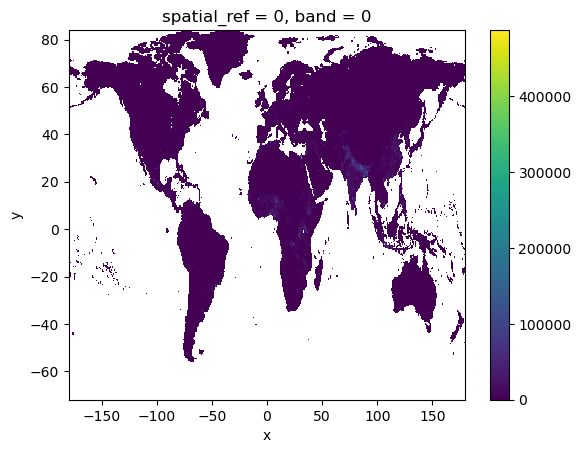

/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_execute_task(a, cache) for a in args))
/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_execute_task(a, cache) for a in args))
/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_execute_task(a, cache) for a in args))
/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_execute_task(a, cache) for a in args))
/apps/brussel/RL8/zen2-ib/software/dask/2023.9.2-foss-2023a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in add
  return func(*(_exec

In [12]:
da.isel(band=0).plot()

plt.show()

## open nAHD

### 1) open GCM nAHD

In [13]:
dirname='output_empirical'
models='ISIMIP3b'

year=2023

da_nAHD_mod_emp = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year)

### 2) open reanalysis shift fit results

In [14]:
dir_shift_fit = 'forster2024-hitol-nan'
start_year = 1950
datasets=datasets[0:3]
datasets

['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5']

In [15]:
# open data
flags['models']='ISIMIP3a'
dirname = 'output_shift-fit' 

da_list = []

for i in range(len(datasets)):
    dataset = datasets[i]
    filepath = glob.glob(os.path.join(outdirs, 
                                      f'{dirname}/{dir_shift_fit}/WBGT/ISIMIP3a/{dataset}/*_obsclim_WBGT_params_shift_loc_mon_{start_year}_2019.nc'))[0]
    da = xr.open_dataarray(filepath).expand_dims("dataset").assign_coords(dataset=("dataset", [dataset]))
    da_list.append(da)
    da_params = xr.concat(da_list, dim="dataset")

# covariate
gmst_smo = get_gmst_smo(ntime=4, observed_warming_path=observed_warming_path_annual)



In [16]:
# calc nAHD
threshold = 28
da_nAHD_obs, da_nAHD_mo, da_p0, da_p1 = calc_nAHD_shift_fit(da_params, threshold, gmst_smo,year_pres=2023,GWI=1.3)


## Test result with WorldPop data

In [17]:
da_nAHD_obs

<xarray.DataArray (dataset: 3, lat: 360, lon: 720)>
array([[[ 4.54639593e-13,  4.54735504e-13,  4.54647967e-13, ...,
          3.07911652e-13,  3.07819007e-13,  3.76316139e-13],
        [ 4.01265297e-13,  4.00892718e-13,  4.00718450e-13, ...,
          2.95752139e-13,  2.95622872e-13,  3.46954085e-13],
        [ 3.76402964e-13,  3.75933111e-13,  3.75513618e-13, ...,
          3.48693199e-13,  3.47580459e-13,  3.57026846e-13],
        ...,
        [-1.35919708e-32, -1.38977417e-32, -1.45282199e-32, ...,
         -1.26221220e-32, -1.29653099e-32, -1.35990960e-32],
        [-8.92565071e-35, -8.50661938e-35, -8.33832532e-35, ...,
         -1.46283722e-34, -1.43337138e-34, -1.33749777e-34],
        [ 6.68600246e-35,  6.83588294e-35,  7.17836604e-35, ...,
          6.87853989e-35,  7.13492579e-35,  8.42264345e-35]],

       [[ 6.75173255e-15,  6.73959984e-15,  6.71952370e-15, ...,
          6.78052671e-15,  6.77821438e-15,  6.76696714e-15],
        [ 6.93086251e-15,  6.89088392e-15,  6.86073806e-15, ...,
          7.00178226e-15,  6.98018361e-15,  6.96128830e-15],
        [ 7.38939401e-15,  7.28132295e-15,  7.27817798e-15, ...,
          7.44658964e-15,  7.38403043e-15,  7.42715100e-15],
...
        [ 1.05832667e-36,  1.10644841e-36,  1.15663762e-36, ...,
          9.13066210e-37,  9.67955926e-37,  1.01541922e-36],
        [ 1.78811631e-36,  1.83435319e-36,  1.89011871e-36, ...,
          1.77813457e-36,  1.76224074e-36,  1.75441493e-36],
        [ 3.31804672e-35,  3.30711573e-35,  3.38678774e-35, ...,
          3.22389712e-35,  3.25512702e-35,  3.30021488e-35]],

       [[ 6.75173255e-15,  6.73959984e-15,  6.71952370e-15, ...,
          6.78052671e-15,  6.77821438e-15,  6.76696714e-15],
        [ 6.93086251e-15,  6.89088392e-15,  6.86073806e-15, ...,
          7.00178226e-15,  6.98018361e-15,  6.96128830e-15],
        [ 7.38939401e-15,  7.28132295e-15,  7.27817798e-15, ...,
          7.44658964e-15,  7.38403043e-15,  7.42715100e-15],
        ...,
        [ 2.66440819e-36,  2.72289422e-36,  2.86640180e-36, ...,
          2.36540454e-36,  2.49491260e-36,  2.55718426e-36],
        [ 7.86204387e-37,  7.86595906e-37,  8.15878462e-37, ...,
          8.03025498e-37,  7.96896343e-37,  7.77038103e-37],
        [ 2.95185365e-36,  2.90830158e-36,  3.04673900e-36, ...,
          2.85958182e-36,  2.91133685e-36,  2.91332044e-36]]])
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

In [18]:
da_worldpop


<xarray.DataArray (ages: 18, lat: 312, lon: 720)>
dask.array<where, shape=(18, 312, 720), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * lon          (lon) float64 -179.8 -179.3 -178.8 -178.3 ... 178.7 179.2 179.7
  * lat          (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
    spatial_ref  int64 0
  * ages         (ages) int64 0 1 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80

In [19]:
da_nAHD_obs_reindex = da_nAHD_obs.reindex_like(da_worldpop, method="nearest")

da_nAHD_obs_reindex
# remap if different lat lon

<xarray.DataArray (dataset: 3, lat: 312, lon: 720)>
array([[[ 3.67326443e-13,  3.67243008e-13,  3.70695542e-13, ...,
          3.30195545e-13,  3.36111472e-13,  3.38588969e-13],
        [ 3.99499536e-13,  3.99863136e-13,  4.03795296e-13, ...,
          3.77556676e-13,  3.91035210e-13,  3.92689895e-13],
        [ 6.00114374e-13,  5.89458534e-13,  5.88988174e-13, ...,
          6.22740843e-13,  6.36706567e-13,  6.15777492e-13],
        ...,
        [-7.14307905e-10, -7.50978249e-10, -7.87402472e-10, ...,
         -1.37118799e-10, -1.74781840e-10, -3.35954932e-10],
        [-1.48584486e-10, -1.58897123e-10, -1.68493746e-10, ...,
         -1.97008838e-11, -2.60222686e-11, -5.94595533e-11],
        [-9.51730539e-12, -9.60927240e-12, -1.20119401e-11, ...,
         -1.10510158e-12, -1.53925358e-12, -3.86672895e-12]],

       [[ 1.65943734e-14,  1.61070909e-14,  1.59383843e-14, ...,
          1.60654695e-14,  1.60735019e-14,  1.64938226e-14],
        [ 1.73826540e-14,  1.70797083e-14,  1.70257488e-14, ...,
          1.65152381e-14,  1.65841201e-14,  1.72928423e-14],
        [ 2.21369823e-14,  2.12907921e-14,  2.08988661e-14, ...,
          2.11294673e-14,  2.11436657e-14,  2.19766021e-14],
...
        [ 1.44114369e-12,  4.63400140e-11,  1.47634792e-10, ...,
         -1.30265771e-11, -1.72337965e-11, -1.55014596e-11],
        [-6.19563686e-12, -2.59706306e-12,  9.07199095e-12, ...,
         -2.20986459e-12, -3.81652931e-12, -5.57546415e-12],
        [-9.39271305e-14,  2.96798091e-13,  1.29606091e-12, ...,
         -6.45237871e-14, -1.36763436e-13, -1.90673253e-13]],

       [[ 1.65943734e-14,  1.61070909e-14,  1.59383843e-14, ...,
          1.60654695e-14,  1.60735019e-14,  1.64938226e-14],
        [ 1.73826540e-14,  1.70797083e-14,  1.70257488e-14, ...,
          1.65152381e-14,  1.65841201e-14,  1.72928423e-14],
        [ 2.21369823e-14,  2.12907921e-14,  2.08988661e-14, ...,
          2.11294673e-14,  2.11436657e-14,  2.19766021e-14],
        ...,
        [ 1.44114369e-12,  4.63400140e-11,  1.47634792e-10, ...,
         -1.30265771e-11, -1.72337965e-11, -1.55014596e-11],
        [-6.19563686e-12, -2.59706306e-12,  9.07199095e-12, ...,
         -2.20986459e-12, -3.81652931e-12, -5.57546415e-12],
        [-9.39271305e-14,  2.96798091e-13,  1.29606091e-12, ...,
         -6.45237871e-14, -1.36763436e-13, -1.90673253e-13]]])
Coordinates:
  * lon      (lon) float64 -179.8 -179.3 -178.8 -178.3 ... 178.7 179.2 179.7
  * lat      (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

In [20]:
def calc_number_proportion_people_atleastxdays_10yr_worldpop(gs_population, 
                                                    GCMs, 
                                                    da_nAHD,  
                                                    age_ranges = np.arange(0, 90, 10), #0-9 ... 90-99
                                                    x_hot_days = [1,5,10,20,50]):


    grouped_data = gs_population.groupby_bins('ages', age_ranges, right=False).sum() # right boundary excluded i.e. [0,9)

    # calculate number and proportion of people exposed to at least x nAHD
    # initiate empty dataarray 
    da_master = None
    
    for GCM in GCMs:
        # initiate empty dataframe
        columns = {f'n_atleast_{x}': np.nan for x in x_hot_days}
        columns.update({f'prop_atleast_{x}': np.nan for x in x_hot_days})
        df_out = pd.DataFrame(index=age_ranges[:-1], columns=columns)
        
        # open da_nAHD
        da_nAHD_mod = da_nAHD.sel(model=GCM)
        
        # calculate - loop over each age bin and each threshold 
        for i in range(len(grouped_data.ages_bins)):
            for x in x_hot_days:

                # number of people living through at least x heatwaves 
                n_people_at_least_x = grouped_data.isel(ages_bins=i).where(da_nAHD_mod>=x).sum().values
                df_out.loc[age_ranges[i],f'n_atleast_{x}'] = float(n_people_at_least_x)

                # proportion of people living through at least x heatwaves
                prop_at_least_x = n_people_at_least_x / grouped_data.isel(ages_bins=i).sum().values
                df_out.loc[age_ranges[i],f'prop_atleast_{x}'] = prop_at_least_x
        
        # convert to dataarray
        da = xr.DataArray(df_out, dims = ('age_ranges', 'features')).assign_coords(model=GCM) 
        
        # concat for all GCMs
        if da_master is None:
            da_master = da.copy()
        else:
            da_master = xr.concat([da_master, da], dim='model')
    
    da_n_people = da_master.isel(features=slice(0, len(da_master.features) //2))
    da_n_people.name = 'number of people'
    da_prop_people = da_master.isel(features=slice(len(da_master.features) //2, len(da_master.features))) 
    da_prop_people.name = 'proportion'
        
    return da_n_people, da_prop_people

In [21]:
da_worldpop

<xarray.DataArray (ages: 18, lat: 312, lon: 720)>
dask.array<where, shape=(18, 312, 720), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * lon          (lon) float64 -179.8 -179.3 -178.8 -178.3 ... 178.7 179.2 179.7
  * lat          (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
    spatial_ref  int64 0
  * ages         (ages) int64 0 1 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80

In [22]:
age_ranges = np.arange(0, 95, 10)
da_worldpop.groupby_bins('ages', age_ranges, right=False) #.sum().isel(ages_bins=0).sum().values

DataArrayGroupBy, grouped over 'ages_bins'
9 groups with labels [0,, 10), [10,, 20), ..., [80,, 90).

In [23]:
for i in range(len(age_ranges)-1):
    print(i)
    print(da_worldpop.groupby_bins('ages', age_ranges, right=False).sum().isel(ages_bins=i).sum().values)

0
1376129500.0
1
1279259300.0
2
1226451600.0
3
1186285600.0
4
990429300.0
5
846905200.0
6
597316600.0
7
315764740.0
8
149294100.0


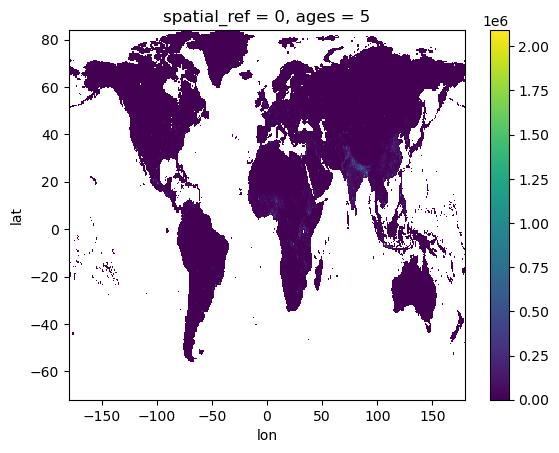

In [24]:
da_worldpop.isel(ages=2).plot()

In [25]:
for i in range(len(da_worldpop.ages)):
    print(da_worldpop.ages[i].values)
    print(da_worldpop.isel(ages=i).sum().values)

0
139410350.0
1
555244000.0
5
681475140.0
10
655539460.0
15
623719800.0
20
607351900.0
25
619099650.0
30
625990340.0
35
560295300.0
40
504373860.0
45
486055500.0
50
453066800.0
55
393838460.0
60
325659460.0
65
271657180.0
70
190430530.0
75
125334190.0
80
149294100.0


In [26]:

da_n_people_ndays_obs, da_prop_people_ndays_obs = calc_number_proportion_people_atleastxdays_10yr_worldpop(da_worldpop, 
                                                                                          datasets, 
                                                                                          da_nAHD_obs_reindex.rename({'dataset':'model'}),  
                                                                                          age_ranges = np.arange(0, 95, 10),
                                                                                          x_hot_days = [1,5,10,20,50])



In [27]:
# days per capita 
gs_population = da_worldpop
da_nAHD = da_nAHD_obs_reindex

grouped_data = gs_population.groupby_bins('ages', age_ranges, right=False).sum()

people_days = grouped_data * da_nAHD

days_percap = people_days.sum(dim=['lat', 'lon']) / grouped_data.sum(dim=['lat', 'lon'])

days_percap['ages_bins']=da_n_people_ndays_obs['age_ranges'].values

days_percap

<xarray.DataArray (ages_bins: 9, dataset: 3)>
dask.array<truediv, shape=(9, 3), dtype=float64, chunksize=(1, 3), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 0
  * dataset      (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * ages_bins    (ages_bins) int64 0 10 20 30 40 50 60 70 80

In [28]:
da_n_people_ndays_obs

<xarray.DataArray 'number of people' (model: 3, age_ranges: 9, features: 5)>
array([[[898522816.0, 788721728.0, 725114176.0, 622013376.0,
         297280480.0],
        [838766144.0, 737399424.0, 679693696.0, 582468800.0,
         275903456.0],
        [798070016.0, 696468544.0, 633577728.0, 539560448.0,
         256197824.0],
        [732786560.0, 628726464.0, 566675072.0, 475248320.0,
         221180416.0],
        [595085760.0, 499696224.0, 446238304.0, 369214272.0,
         176510016.0],
        [479362624.0, 391563968.0, 342667040.0, 281184640.0,
         132929688.0],
        [323950720.0, 259091104.0, 225014704.0, 181062688.0, 84635632.0],
        [167489504.0, 130400768.0, 111214800.0, 84457120.0, 38467320.0],
        [75254768.0, 55874120.0, 46450384.0, 32380782.0, 13654856.0]],

       [[902542976.0, 738647040.0, 642555200.0, 521753280.0,
         199684704.0],
        [842940416.0, 688856640.0, 602432320.0, 495492608.0,
         189065344.0],
...
        [353216640.0, 242477856.0, 191097200.0, 149679824.0, 56104292.0],
        [178665744.0, 115317624.0, 89404848.0, 68228760.0, 25572224.0],
        [78048648.0, 46359460.0, 35221552.0, 26627280.0, 9811517.0]],

       [[948618432.0, 810075840.0, 738130432.0, 623806976.0,
         309277120.0],
        [886691520.0, 755378176.0, 690575488.0, 583434368.0,
         291817184.0],
        [847259136.0, 711036096.0, 644071168.0, 540905728.0,
         267778992.0],
        [783154304.0, 634895808.0, 567647680.0, 470327616.0,
         228647328.0],
        [641569344.0, 500799520.0, 441896416.0, 363892512.0,
         181595776.0],
        [527310848.0, 392513696.0, 338952096.0, 273423712.0,
         137393488.0],
        [356635264.0, 256444752.0, 218734464.0, 175814704.0, 87613896.0],
        [182076128.0, 124559488.0, 102158288.0, 80872576.0, 39655252.0],
        [80215304.0, 50941448.0, 39929080.0, 30796612.0, 14073064.0]]],
      dtype=object)
Coordinates:
  * age_ranges  (age_ranges) int64 0 10 20 30 40 50 60 70 80
  * features    (features) object 'n_atleast_1' 'n_atleast_5' ... 'n_atleast_50'
  * model       (model) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

In [29]:
da_n_people_ndays_obs.sel(features='n_atleast_20')

<xarray.DataArray 'number of people' (model: 3, age_ranges: 9)>
array([[622013376.0, 582468800.0, 539560448.0, 475248320.0, 369214272.0,
        281184640.0, 181062688.0, 84457120.0, 32380782.0],
       [521753280.0, 495492608.0, 458771840.0, 403981344.0, 311214912.0,
        234949280.0, 149679824.0, 68228760.0, 26627280.0],
       [623806976.0, 583434368.0, 540905728.0, 470327616.0, 363892512.0,
        273423712.0, 175814704.0, 80872576.0, 30796612.0]], dtype=object)
Coordinates:
  * age_ranges  (age_ranges) int64 0 10 20 30 40 50 60 70 80
    features    <U12 'n_atleast_20'
  * model       (model) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

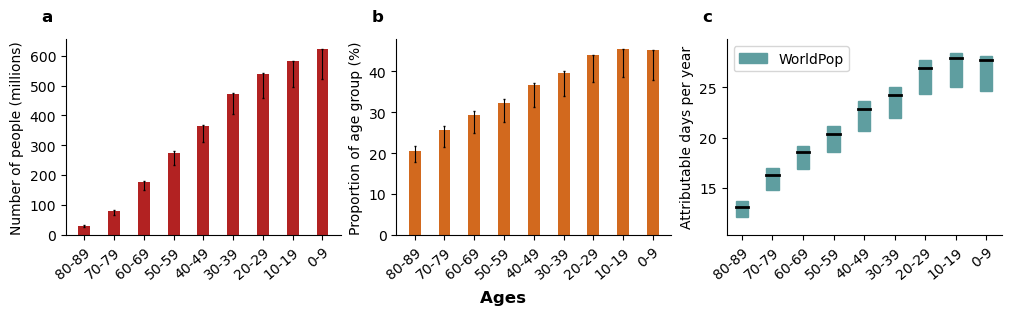

In [30]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,3,figsize=(10,3),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()


ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_obs.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='WorldPop'
                                             )


ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_obs.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='WorldPop'
)

ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
plot = plot_percapitadays_median_iqr(days_percap.to_pandas().T,
                              ax=ax,
                             set_xticklabel=True,
                             ylabel='Attributable days per year')

col = 'cadetblue'
for patch in [plot['boxes'][0]]:
    patch.set_facecolor(col)
    patch.set_label('WorldPop')   # <- now the label is attached to the patch

# Add legend
ax.legend()


ax.set_ylabel('Attributable days per year')


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


#plt.savefig(os.path.join(figdir,'fig2-median.png'),dpi=300,bbox_inches='tight',transparent=True)
#plt.savefig(os.path.join(figdir,'fig2-median.pdf'),dpi=300,bbox_inches='tight',transparent=True)

### Same analysis with my data for 2020

In [31]:
# import other packages/modules 
sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/'))
from population_demographics import * 

In [32]:
gs_population_global = population_demographics_gridscale_global(startyear=2020,
                                                                endyear=2020,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [33]:
da_n_people_ndays_obs_orig, da_prop_people_ndays_obs_orig = calc_number_proportion_people_atleastxdays_10yr_worldpop(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD_obs.rename({'dataset':'model'}),  
                                                                                          age_ranges = np.arange(0, 95, 10),
                                                                                          x_hot_days = [1,5,10,20,50])

In [34]:
da_n_people_ndays_obs

<xarray.DataArray 'number of people' (model: 3, age_ranges: 9, features: 5)>
array([[[898522816.0, 788721728.0, 725114176.0, 622013376.0,
         297280480.0],
        [838766144.0, 737399424.0, 679693696.0, 582468800.0,
         275903456.0],
        [798070016.0, 696468544.0, 633577728.0, 539560448.0,
         256197824.0],
        [732786560.0, 628726464.0, 566675072.0, 475248320.0,
         221180416.0],
        [595085760.0, 499696224.0, 446238304.0, 369214272.0,
         176510016.0],
        [479362624.0, 391563968.0, 342667040.0, 281184640.0,
         132929688.0],
        [323950720.0, 259091104.0, 225014704.0, 181062688.0, 84635632.0],
        [167489504.0, 130400768.0, 111214800.0, 84457120.0, 38467320.0],
        [75254768.0, 55874120.0, 46450384.0, 32380782.0, 13654856.0]],

       [[902542976.0, 738647040.0, 642555200.0, 521753280.0,
         199684704.0],
        [842940416.0, 688856640.0, 602432320.0, 495492608.0,
         189065344.0],
...
        [353216640.0, 242477856.0, 191097200.0, 149679824.0, 56104292.0],
        [178665744.0, 115317624.0, 89404848.0, 68228760.0, 25572224.0],
        [78048648.0, 46359460.0, 35221552.0, 26627280.0, 9811517.0]],

       [[948618432.0, 810075840.0, 738130432.0, 623806976.0,
         309277120.0],
        [886691520.0, 755378176.0, 690575488.0, 583434368.0,
         291817184.0],
        [847259136.0, 711036096.0, 644071168.0, 540905728.0,
         267778992.0],
        [783154304.0, 634895808.0, 567647680.0, 470327616.0,
         228647328.0],
        [641569344.0, 500799520.0, 441896416.0, 363892512.0,
         181595776.0],
        [527310848.0, 392513696.0, 338952096.0, 273423712.0,
         137393488.0],
        [356635264.0, 256444752.0, 218734464.0, 175814704.0, 87613896.0],
        [182076128.0, 124559488.0, 102158288.0, 80872576.0, 39655252.0],
        [80215304.0, 50941448.0, 39929080.0, 30796612.0, 14073064.0]]],
      dtype=object)
Coordinates:
  * age_ranges  (age_ranges) int64 0 10 20 30 40 50 60 70 80
  * features    (features) object 'n_atleast_1' 'n_atleast_5' ... 'n_atleast_50'
  * model       (model) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

In [35]:

da_nAHD_percapita_peopledays_10y_obs_orig = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD_obs.rename({'dataset':'model'}),  
                                                                           x_hot_days = [1, 5, 10, 20, 50], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [36]:
da_nAHD_percapita_peopledays_10y_obs_orig.sel(features='per_capita_days').to_pandas()

age_ranges,0,10,20,30,40,50,60,70,80,90
model,,,,,,,,,,
GSWP3-W5E5,28.518001,28.432275,27.062531,24.509996,23.430602,20.864186,19.175179,16.877425,13.971368,11.687904
20CRv3-ERA5,21.548660,21.645414,20.783196,18.952541,18.004127,16.321748,14.992730,13.121641,11.019648,9.320470
20CRv3-W5E5,27.627484,27.373253,25.867477,23.258629,22.075721,19.687278,18.102808,15.809119,12.907559,10.506227


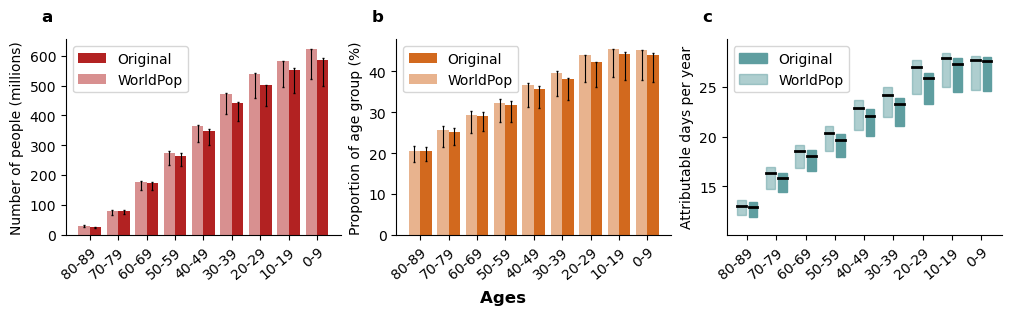

In [37]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,3,figsize=(10,3),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()


ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_obs_orig.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='Original',
                                              offset = -.2
                                             )

plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_obs.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='WorldPop',
                                              alpha=.5,
                                              offset = .2
                                             )

ax.legend()


ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_obs_orig.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Original',
                                              offset = -.2
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_obs.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='WorldPop',
                                              alpha=.5,
                                              offset = .2
)

ax.legend()

ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
plot = plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_orig.sel(features='per_capita_days').to_pandas().iloc[:,:-1],
                              ax=ax,
                             set_xticklabel=False,
                             ylabel='Attributable days per year',
                             offset=-.2,
                             widths=.3)

plot2 = plot_percapitadays_median_iqr(days_percap.to_pandas().T,
                              ax=ax,
                             set_xticklabel=True,
                             ylabel='Attributable days per year',
                             offset=.2,
                             widths=.3
                             )
                             

col = 'cadetblue'
for patch in [plot['boxes'][0]]:
    patch.set_facecolor(col)
    patch.set_label('Original')   # <- now the label is attached to the patch


for patch in plot2['boxes']:
    patch.set_alpha(.5)

col = 'cadetblue'
for patch in [plot2['boxes'][0]]:
    patch.set_facecolor(col)
    patch.set_label('WorldPop')   # <- now the label is attached to the patch


# Add legend
ax.legend()


ax.set_ylabel('Attributable days per year')


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_worlpop_sensitivity.png'),bbox_inches='tight',dpi=300)


In [38]:
df_orig = da_n_people_ndays_obs_orig.sel(features='n_atleast_20').to_pandas().T 

df=df_orig
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
age_ranges,,,
0,1.0,1.0,1.0
10,1.1,1.0,1.1
20,1.2,1.2,1.2
30,1.3,1.3,1.3
40,1.7,1.6,1.7
50,2.1,2.1,2.2
60,3.3,3.3,3.4
70,7.2,7.1,7.5
80,21.9,21.6,22.9


In [39]:
df_worldpop = da_n_people_ndays_obs.sel(features='n_atleast_20').to_pandas().T 
df=df_worldpop
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
age_ranges,,,
0,1.0,1.0,1.0
10,1.1,1.1,1.1
20,1.2,1.1,1.2
30,1.3,1.3,1.3
40,1.7,1.7,1.7
50,2.2,2.2,2.3
60,3.5,3.4,3.5
70,7.6,7.4,7.7
80,19.6,19.2,20.3


In [40]:
df_worldpop.sum(axis=0).median() / 1e9

3.143274804

In [41]:
df_orig.sum(axis=0).median() /1e9

2.987548299606352

In [42]:
df_orig = da_prop_people_ndays_obs_orig.sel(features='prop_atleast_20').to_pandas().T 

df=df_orig
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
age_ranges,,,
0,1.0,1.0,1.0
10,1.0,1.0,1.0
20,1.0,1.0,1.1
30,1.1,1.1,1.2
40,1.2,1.2,1.2
50,1.4,1.3,1.4
60,1.5,1.5,1.5
70,1.7,1.7,1.8
80,2.1,2.1,2.2


In [43]:
df_worldpop = da_prop_people_ndays_obs.sel(features='prop_atleast_20').to_pandas().T 

df=df_worldpop
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
age_ranges,,,
0,1.0,1.0,1.0
10,1.0,1.0,1.0
20,1.0,1.0,1.0
30,1.1,1.1,1.1
40,1.2,1.2,1.2
50,1.4,1.4,1.4
60,1.5,1.5,1.5
70,1.8,1.7,1.8
80,2.1,2.1,2.2


In [44]:
df_orig = da_nAHD_percapita_peopledays_10y_obs_orig.sel(features='per_capita_days').to_pandas().iloc[:,:-1].T
df=df_orig
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
age_ranges,,,
0,1.0,1.0,1.0
10,1.0,1.0,1.0
20,1.1,1.0,1.1
30,1.2,1.1,1.2
40,1.2,1.2,1.3
50,1.4,1.3,1.4
60,1.5,1.4,1.5
70,1.7,1.6,1.7
80,2.0,2.0,2.1


In [45]:
df_worldpop = days_percap.to_pandas()

df=df_worldpop
(df.iloc[0].values / df).agg(['median', 'min', 'max'],axis=1).round(1)

,median,min,max
ages_bins,,,
0,1.0,1.0,1.0
10,1.0,1.0,1.0
20,1.0,1.0,1.0
30,1.1,1.1,1.1
40,1.2,1.2,1.2
50,1.3,1.3,1.4
60,1.4,1.4,1.5
70,1.6,1.6,1.7
80,2.0,1.9,2.1


In [46]:
# different pop distribution 

gs_population_global.sum(dim=['ages','lat','lon'])

<xarray.DataArray (time: 1)>
array([7.78974774e+09])
Coordinates:
  * time     (time) int64 2020

In [47]:
da_worldpop.sum(dim=['ages','lat','lon']).values

array(7.9678356e+09, dtype=float32)

In [75]:
da_worldpop.sum(dim=['ages','lat','lon']).values - gs_population_global.sum(dim=['ages','lat','lon'])

<xarray.DataArray (time: 1)>
array([1.78087903e+08])
Coordinates:
  * time     (time) int64 2020

In [48]:
da_worldpop

<xarray.DataArray (ages: 18, lat: 312, lon: 720)>
dask.array<where, shape=(18, 312, 720), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * lon          (lon) float64 -179.8 -179.3 -178.8 -178.3 ... 178.7 179.2 179.7
  * lat          (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
    spatial_ref  int64 0
  * ages         (ages) int64 0 1 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80

In [49]:
gs_population_global

<xarray.DataArray (time: 1, lat: 360, lon: 720, ages: 105)>
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * time     (time) int64 2020
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [50]:
da_worldpop = da_worldpop.assign_coords(
    lat=da_worldpop.lat.round(2),
    lon=da_worldpop.lon.round(2)
)

gs_population_global = gs_population_global.assign_coords(
    lat=gs_population_global.lat.round(2),
    lon=gs_population_global.lon.round(2)
)

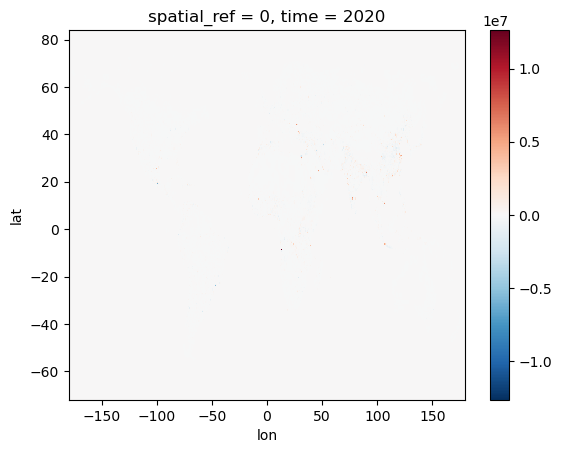

In [51]:
(da_worldpop.sum(dim='ages') - gs_population_global.sum(dim='ages')).plot()

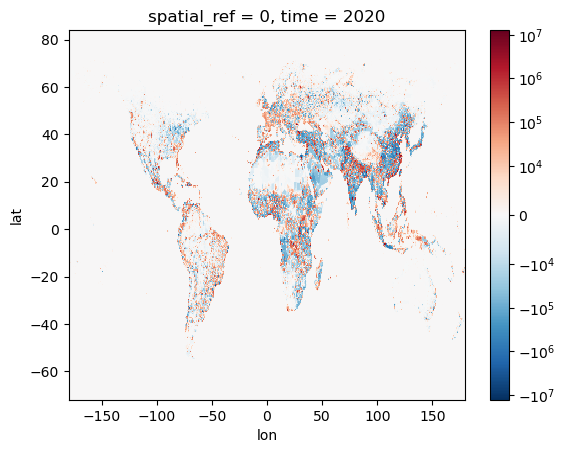

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

diff = da_worldpop.sum(dim='ages') - gs_population_global.sum(dim='ages')

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

diff.plot(
    norm=norm,
    cmap='RdBu_r'
)

plt.show()

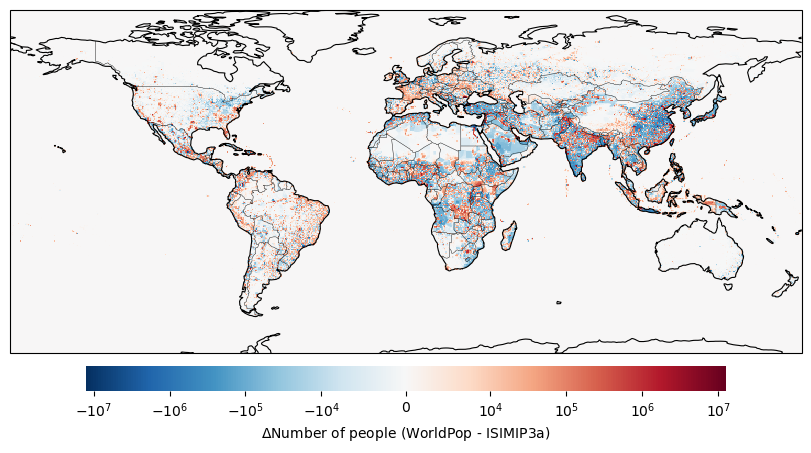

In [59]:

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Settings
proj = crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8,5),layout='constrained',subplot_kw={'projection': crs})


diff = da_worldpop.sum(dim='ages') - gs_population_global.sum(dim='ages')

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

plot = diff.plot(
    ax=ax,
    norm=norm,
    cmap='RdBu_r',
    add_colorbar=False
    )

ax.set_title('')
ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cax = fig.add_axes([0.1, 0.08, 0.8, 0.05])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('$\Delta$Number of people (WorldPop - ISIMIP3a)' )
cbar.outline.set_edgecolor('none')


# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_worlpop_totalpopdifference.png'),bbox_inches='tight',dpi=300)

In [64]:
da_worldpop.sel(ages=slice(0,9)).sum(dim='ages') / da_worldpop.sum(dim='ages') 

<xarray.DataArray (lat: 312, lon: 720)>
dask.array<truediv, shape=(312, 720), dtype=float32, chunksize=(100, 100), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 0
  * lat          (lat) float64 83.75 83.25 82.75 82.25 ... -70.75 -71.25 -71.75
  * lon          (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [66]:
gs_population_global.sel(ages=slice(0,9)).sum(dim='ages') / gs_population_global.sum(dim='ages') 

<xarray.DataArray (time: 1, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) int64 2020
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

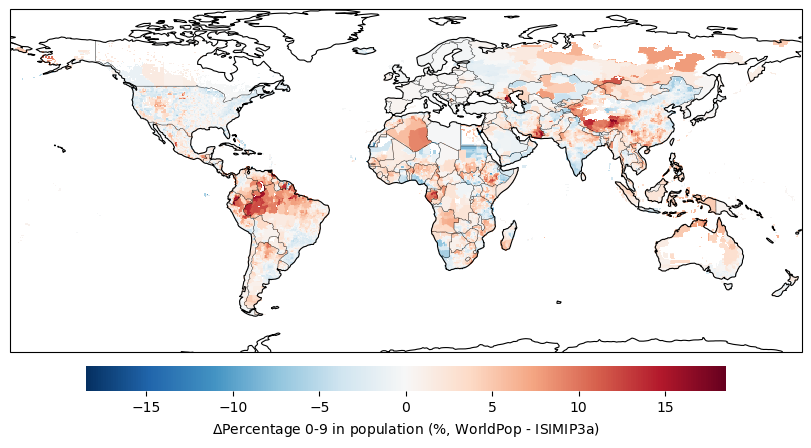

In [ ]:

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Settings
proj = crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8,5),layout='constrained',subplot_kw={'projection': crs})


diff = da_worldpop.sel(ages=slice(0,9)).sum(dim='ages') / da_worldpop.sum(dim='ages')  - gs_population_global.sel(ages=slice(0,9)).sum(dim='ages') / gs_population_global.sum(dim='ages') 

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

plot = (diff*100).plot(
    ax=ax,
    #norm=norm,
    cmap='RdBu_r',
    add_colorbar=False
    )

ax.set_title('')
ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cax = fig.add_axes([0.1, 0.08, 0.8, 0.05])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('$\Delta$Percentage 0-9 in population (%, WorldPop - ISIMIP3a)' )
cbar.outline.set_edgecolor('none')


# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_worlpop_percentage_09_inpopulation.png'),bbox_inches='tight',dpi=300)

In [61]:
diff.sum().values

array(1.78088411e+08)

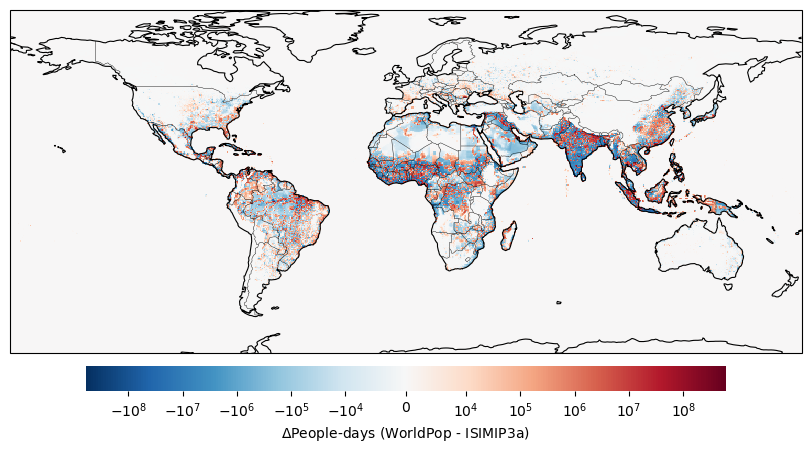

In [57]:

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Settings
proj = crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8,5),layout='constrained',subplot_kw={'projection': crs})

people_days_worldpop = (da_worldpop * da_nAHD_obs).mean(dim='dataset').sum(dim='ages')
people_days_orig = (gs_population_global * da_nAHD_obs).mean(dim='dataset').sum(dim='ages')

diff = people_days_worldpop - people_days_orig

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

plot = diff.plot(
    ax=ax,
    norm=norm,
    cmap='RdBu_r',
    add_colorbar=False
    )

ax.set_title('')
ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cax = fig.add_axes([0.1, 0.08, 0.8, 0.05])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('$\Delta$People-days (WorldPop - ISIMIP3a)' )
cbar.outline.set_edgecolor('none')



In [73]:
### Plot all as subplots

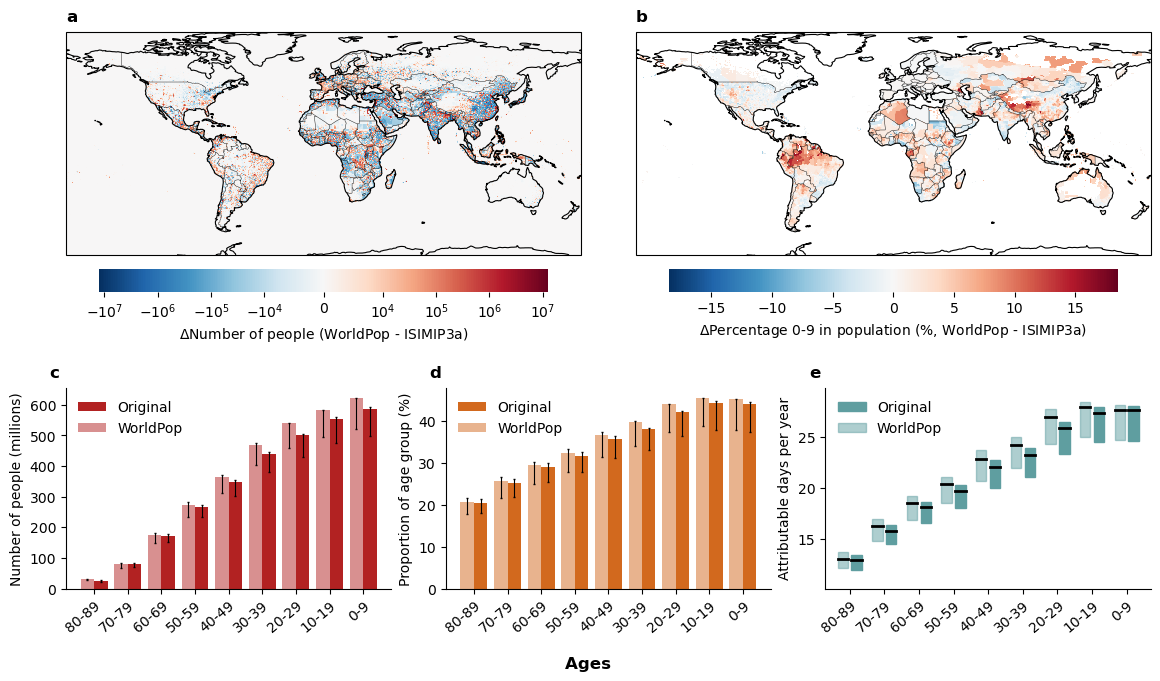

In [ ]:
from matplotlib.gridspec import GridSpec

# settings
xpos=0
ypos=1.01


proj = crs = ccrs.PlateCarree()

# Figure 
fig = plt.figure(figsize=(14, 7.5))

gs = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,
    width_ratios=[1,1,1,1,1,1],
    height_ratios=[1.4,1],
    hspace=0.4,
    wspace=0.4,
)

# Top centered map (spans both columns)
ax1 = fig.add_subplot(gs[0, :3], projection=crs)
ax2 = fig.add_subplot(gs[0, 3:], projection=crs)

ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes = [ax1,ax2,ax3,ax4,ax5 ]



#a
ax=ax1
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)

diff = da_worldpop.sum(dim='ages') - gs_population_global.sum(dim='ages')

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

plot = diff.plot(
    ax=ax,
    norm=norm,
    cmap='RdBu_r',
    add_colorbar=False
    )

ax.set_title('')
ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cbar = fig.colorbar(plot, ax=ax, location='bottom', shrink=1, fraction=0.08, pad=0.05)
cbar.set_label('$\Delta$Number of people (WorldPop - ISIMIP3a)' )
cbar.outline.set_edgecolor('none')


# b
ax=ax2
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)

diff = da_worldpop.sel(ages=slice(0,9)).sum(dim='ages') / da_worldpop.sum(dim='ages')  - gs_population_global.sel(ages=slice(0,9)).sum(dim='ages') / gs_population_global.sum(dim='ages') 

norm = colors.SymLogNorm(
    linthresh=1e4,   # linear range around zero (adjust!)
    linscale=1,

)

plot = (diff*100).plot(
    ax=ax,
    #norm=norm,
    cmap='RdBu_r',
    add_colorbar=False
    )

ax.set_title('')
ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cbar = fig.colorbar(plot, ax=ax, location='bottom', shrink=1, fraction=0.08, pad=0.05)
cbar.set_label('$\Delta$Percentage 0-9 in population (%, WorldPop - ISIMIP3a)' )
cbar.outline.set_edgecolor('none')



#c
xpos=-.05

ax=ax3
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_obs_orig.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='Original',
                                              offset = -.2
                                             )

plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_obs.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='WorldPop',
                                              alpha=.5,
                                              offset = .2
                                             )



ax=ax4
ax.set_title('d',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_obs_orig.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Original',
                                              offset = -.2
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_obs.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='WorldPop',
                                              alpha=.5,
                                              offset = .2
)


ax=ax5
ax.set_title('e',loc='left',fontweight='bold',x=xpos,y=ypos)
plot = plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_orig.sel(features='per_capita_days').to_pandas().iloc[:,:-1],
                              ax=ax,
                             set_xticklabel=False,
                             ylabel='Attributable days per year',
                             offset=-.2,
                             widths=.3)

plot2 = plot_percapitadays_median_iqr(days_percap.to_pandas().T,
                              ax=ax,
                             set_xticklabel=True,
                             ylabel='Attributable days per year',
                             offset=.2,
                             widths=.3
                             )
                             

col = 'cadetblue'
for patch in [plot['boxes'][0]]:
    patch.set_facecolor(col)
    patch.set_label('Original')   # <- now the label is attached to the patch


for patch in plot2['boxes']:
    patch.set_alpha(.5)

col = 'cadetblue'
for patch in [plot2['boxes'][0]]:
    patch.set_facecolor(col)
    patch.set_label('WorldPop')   # <- now the label is attached to the patch


# Add legend
ax.set_ylabel('Attributable days per year')
fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14


for ax in [ax3,ax4,ax5]:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)





# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_worlpop_subplots.png'),bbox_inches='tight',dpi=300)
